In [1]:
# ==============================
# STEP 1: Data Loaded Directly
# ==============================
# Running locally.

In [2]:
# ==============================
# STEP 2: Import Libraries
# ==============================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import joblib

In [3]:
# ==============================
# STEP 3: Load Dataset
# ==============================
import os
DATASET_PATH = os.path.join("..", "IPF_Validation_Dataset.csv")
df = pd.read_csv(DATASET_PATH)

print("Shape:", df.shape)
df.head()

Shape: (600, 30)


,PatientID,Age,Sex,BMI,SmokingStatus,PackYears,FamilyHistory_ILD,OccupationalExposure,MUC5B_Variant,GERD,...,SpO2_Rest_Percent,HRCT_Pattern,PulmonaryHypertension,Emphysema_CPFE,CardiovascularDisease,KL6_U_per_mL,SPD_ng_per_mL,GAP_Stage,IPF_Severity,IPF_Diagnosis
0,VAL100262,65,Male,34.4,Ex-smoker,36.2,No,Metal dust,Absent,No,...,92,UIP Probable,Yes,Yes,No,574.0,29.8,I,Mild,Yes
1,VAL100133,69,Male,30.4,Never smoked,0.0,Yes,Wood dust,Present,No,...,96,Alternative Diagnosis,Yes,No,No,1429.0,47.0,Not Applicable,Not Applicable,No
2,VAL100576,63,Male,19.0,Ex-smoker,42.3,Yes,Metal dust,Not tested,Yes,...,91,Indeterminate for UIP,Yes,No,No,333.0,37.7,Not Applicable,Not Applicable,No
3,VAL100455,80,Male,29.0,Ex-smoker,5.0,No,NaN,Not tested,No,...,94,UIP Typical,No,No,No,734.0,35.7,III,Severe,Yes
4,VAL100338,55,Male,32.7,Ex-smoker,28.3,No,NaN,Not tested,No,...,94,UIP Probable,No,No,No,1212.0,65.7,I,Mild,Yes


In [4]:
# ==============================
# STEP 4: Basic Dataset Check
# ==============================
print(df.info())
print("\nNull Values:")
print(df.isnull().sum())

print("\nColumns:")
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   PatientID               600 non-null    object 
 1   Age                     600 non-null    int64  
 2   Sex                     600 non-null    object 
 3   BMI                     600 non-null    float64
 4   SmokingStatus           600 non-null    object 
 5   PackYears               600 non-null    float64
 6   FamilyHistory_ILD       600 non-null    object 
 7   OccupationalExposure    219 non-null    object 
 8   MUC5B_Variant           600 non-null    object 
 9   GERD                    600 non-null    object 
 10  mMRC_Dyspnea_Scale      600 non-null    int64  
 11  ChronicCough            600 non-null    object 
 12  VelcroCrackles          600 non-null    object 
 13  DigitalClubbing         600 non-null    object 
 14  FVC_mL                  600 non-null    in

In [5]:
# Keep only diagnosed IPF rows
df = df[df["IPF_Severity"].isin(["Mild", "Moderate", "Severe"])].copy()
# Rename columns to match model expectations
df["FVC"] = df["FVC_mL"]
df["Percent"] = df["FVC_PercentPredicted"]
# Keep only selected 5 features and the severity target
df = df[["FVC", "Percent", "Age", "Sex", "SmokingStatus", "IPF_Severity"]]
df.head()


,FVC,Percent,Age,Sex,SmokingStatus,IPF_Severity
0,3276,78.8,65,Male,Ex-smoker,Mild
3,2534,69.7,80,Male,Ex-smoker,Severe
4,2947,71.1,55,Male,Ex-smoker,Mild
5,3727,100.2,62,Female,Never smoked,Mild
6,4603,106.3,64,Male,Ex-smoker,Mild


In [6]:
# ==============================
# STEP 6: Encode Categorical Columns
# ==============================
label_encoders = {}

categorical_cols = ["Sex", "SmokingStatus", "IPF_Severity"]

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

print("Encoding Done")
df.head()

Encoding Done


,FVC,Percent,Age,Sex,SmokingStatus,IPF_Severity
0,3276,78.8,65,1,1,0
3,2534,69.7,80,1,1,2
4,2947,71.1,55,1,1,0
5,3727,100.2,62,0,2,0
6,4603,106.3,64,1,1,0


In [7]:
# ==============================
# STEP 7: Feature and Target Selection
# ==============================
X = df.drop(columns=["IPF_Severity"])
y = df["IPF_Severity"]

print("Features:", X.columns.tolist())
print("Target classes:", label_encoders["IPF_Severity"].classes_)

Features: ['FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus']
Target classes: ['Mild' 'Moderate' 'Severe']


In [8]:
# ==============================
# STEP 8: Train-Test Split
# ==============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (235, 5)
Testing Shape: (59, 5)


In [9]:
# ==============================
# STEP 9: Feature Scaling
# ==============================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [10]:
# ==============================
# STEP 10: Train Multiple Models
# ==============================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=5,
        random_state=42,
        eval_metric="mlogloss"
    ),
    "CatBoost": CatBoostClassifier(
        iterations=200,
        learning_rate=0.05,
        depth=5,
        random_seed=42,
        verbose=0
    )
}

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name] = acc

    print("Accuracy:", acc)
    print(classification_report(y_test, y_pred))



Training Logistic Regression...
Accuracy: 0.7288135593220338
              precision    recall  f1-score   support

           0       0.78      0.72      0.75        29
           1       0.68      0.78      0.72        27
           2       1.00      0.33      0.50         3

    accuracy                           0.73        59
   macro avg       0.82      0.61      0.66        59
weighted avg       0.74      0.73      0.73        59


Training Random Forest...


Accuracy: 0.6779661016949152
              precision    recall  f1-score   support

           0       0.78      0.72      0.75        29
           1       0.63      0.70      0.67        27
           2       0.00      0.00      0.00         3

    accuracy                           0.68        59
   macro avg       0.47      0.48      0.47        59
weighted avg       0.67      0.68      0.67        59


Training XGBoost...


Accuracy: 0.6440677966101694
              precision    recall  f1-score   support

           0       0.77      0.69      0.73        29
           1       0.60      0.67      0.63        27
           2       0.00      0.00      0.00         3

    accuracy                           0.64        59
   macro avg       0.46      0.45      0.45        59
weighted avg       0.65      0.64      0.65        59


Training CatBoost...


Accuracy: 0.7796610169491526
              precision    recall  f1-score   support

           0       0.83      0.83      0.83        29
           1       0.73      0.81      0.77        27
           2       0.00      0.00      0.00         3

    accuracy                           0.78        59
   macro avg       0.52      0.55      0.53        59
weighted avg       0.74      0.78      0.76        59



C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [11]:
# ==============================
# STEP 11: Compare Model Accuracy
# ==============================
results_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": list(results.values())
})

results_df = results_df.sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy
3,CatBoost,0.779661
0,Logistic Regression,0.728814
1,Random Forest,0.677966
2,XGBoost,0.644068


In [12]:
# ==============================
# STEP 12: Select Best Model
# ==============================
best_model_name = results_df.iloc[0]["Model"]
print("Best Model:", best_model_name)

best_model = models[best_model_name]

Best Model: CatBoost


C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1509: Unde

           BEST MODEL : CatBoost

Accuracy : 0.7797
Precision: 0.7424
Recall   : 0.7797
F1 Score : 0.7600

Classification Report

              precision    recall  f1-score   support

        Mild       0.83      0.83      0.83        29
    Moderate       0.73      0.81      0.77        27
      Severe       0.00      0.00      0.00         3

    accuracy                           0.78        59
   macro avg       0.52      0.55      0.53        59
weighted avg       0.74      0.78      0.76        59



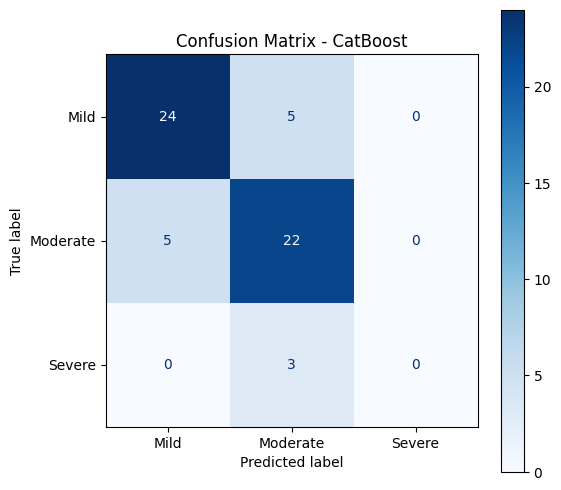

In [13]:
# ==============================
# STEP 13A: Evaluate Best Model
# ==============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt

# Predict using the best model
if best_model_name == "Logistic Regression":
    y_pred_best = best_model.predict(X_test_scaled)
else:
    y_pred_best = best_model.predict(X_test)

# ------------------------------
# Performance Metrics
# ------------------------------
accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best, average='weighted')
recall = recall_score(y_test, y_pred_best, average='weighted')
f1 = f1_score(y_test, y_pred_best, average='weighted')

print("="*60)
print(f"           BEST MODEL : {best_model_name}")
print("="*60)

print(f"\nAccuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# ------------------------------
# Detailed Classification Report
# ------------------------------
print("\nClassification Report\n")
print(classification_report(
    y_test,
    y_pred_best,
    target_names=label_encoders["IPF_Severity"].classes_
))

# ------------------------------
# Confusion Matrix
# ------------------------------
cm = confusion_matrix(y_test, y_pred_best)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoders["IPF_Severity"].classes_
)

fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", values_format='d')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.grid(False)
plt.show()

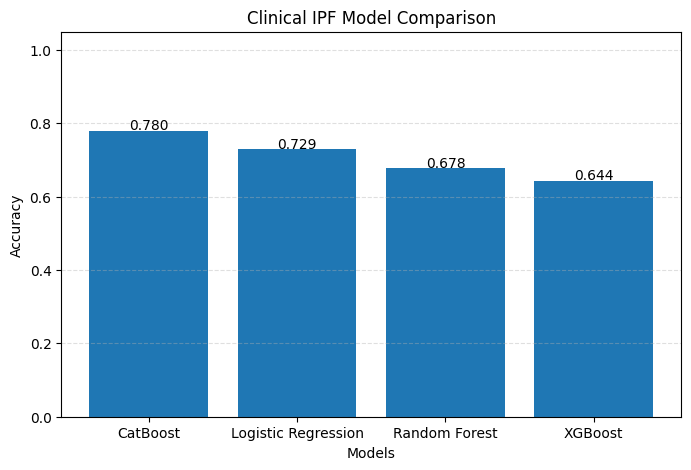

In [14]:
# ==============================
# STEP 13B: Compare All Models
# ==============================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(results_df["Model"], results_df["Accuracy"])

plt.title("Clinical IPF Model Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

for i, v in enumerate(results_df["Accuracy"]):
    plt.text(i, v+0.003, f"{v:.3f}", ha='center', fontsize=10)

plt.ylim(0,1.05)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

In [15]:
# ==============================
# STEP 14: Save Model, Scaler, Encoders
# ==============================
joblib.dump(best_model, "best_ipf_clinical_model.pkl")
joblib.dump(scaler, "ipf_scaler.pkl")
joblib.dump(label_encoders, "ipf_label_encoders.pkl")

print("Model files saved successfully.")

Model files saved successfully.


In [16]:
# ==============================
# STEP 15: Download Saved Files (Optional)
# ==============================
try:
    from google.colab import files
    files.download("best_ipf_clinical_model.pkl")
    files.download("ipf_scaler.pkl")
    files.download("ipf_label_encoders.pkl")
except ImportError:
    print("Saved files locally. (Google Colab files.download skipped)")

Saved files locally. (Google Colab files.download skipped)


In [17]:
# ==============================
# STEP 16: Test Prediction on One Sample
# ==============================

# Take one test sample
sample = X_test.iloc[[0]]

print("Sample Input:")
display(sample.T)   # vertical display to avoid column confusion

print("\nColumn Order:")
print(sample.columns.tolist())

# Prediction
if best_model_name == "Logistic Regression":
    sample_scaled = scaler.transform(sample)
    pred = best_model.predict(sample_scaled)
    prob = best_model.predict_proba(sample_scaled)
else:
    pred = best_model.predict(sample)
    prob = best_model.predict_proba(sample)

# Convert encoded prediction back to original label
predicted_class = label_encoders["IPF_Severity"].inverse_transform(pred)

print("\nPredicted IPF Severity:", predicted_class[0])

# Show probabilities
print("\nPrediction Probabilities:")
for cls, p in zip(label_encoders["IPF_Severity"].classes_, prob[0]):
    print(f"{cls}: {p*100:.2f}%")

Sample Input:


,438
FVC,2585.0
Percent,62.4
Age,81.0
Sex,0.0
SmokingStatus,2.0



Column Order:
['FVC', 'Percent', 'Age', 'Sex', 'SmokingStatus']

Predicted IPF Severity: Moderate

Prediction Probabilities:
Mild: 37.44%
Moderate: 51.88%
Severe: 10.69%


C:\Python311\Lib\site-packages\sklearn\preprocessing\_label.py:153: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
